### Making graphene visible

arXiv:0705.0259v3

Made with Claude Sonnet 4.5

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Wavelength in nanometers
wavelength_data = np.array([380, 400, 450, 500, 550, 600, 650, 700, 750])

# n1: Constant complex refractive index (wavelength independent)
n1 = 2.6 - 1.3j

# n2: Silicon dioxide (SiO₂)
n2_data = np.array([1.470, 1.468, 1.462, 1.458, 1.455, 1.453, 1.451, 1.450, 1.449]) + 0j

# n3: Silicon (Si)
n3_real = np.array([5.60, 5.57, 4.93, 4.27, 4.05, 3.94, 3.85, 3.78, 3.73])
n3_imag = np.array([0.53, 0.39, 0.16, 0.082, 0.038, 0.019, 0.010, 0.0061, 0.0042])
n3_data = n3_real + 1j * n3_imag


# Other parameters
n0 = 1  # air
d1 = 0.34  # nm (graphene thickness)

In [3]:
def compute_intensity(n1_layer, d2, wavelength):
    """
    Compute reflected intensity I as a function of n1 (graphene layer index).
    
    Parameters:
    -----------
    n1_layer : complex
        Refractive index of layer 1 (graphene or air)
    d2 : float or array
        Thickness of SiO2 layer in nm
    wavelength : float or array
        Wavelength in nm
    
    Returns:
    --------
    I : reflected intensity
    """
    
    # Interpolate n2 and n3 for the given wavelength
    n2 = np.interp(wavelength, wavelength_data, n2_data.real) + 0j
    n3 = np.interp(wavelength, wavelength_data, n3_data.real) + 1j * np.interp(wavelength, wavelength_data, n3_data.imag)
    
    # Fresnel reflection coefficients (Eq. 2)
    r1 = (n0 - n1_layer) / (n0 + n1_layer)
    r2 = (n1_layer - n2) / (n1_layer + n2)
    r3 = (n2 - n3) / (n2 + n3)
    
    # Phase shifts
    Phi1 = 2 * np.pi * n1_layer * d1 / wavelength
    Phi2 = 2 * np.pi * n2 * d2 / wavelength
    
    # Intensity (Eq. 1)
    term1 = r1 * np.exp(1j*(Phi1 + Phi2)) + r2 * np.exp(-1j*(Phi1 - Phi2))
    term2 = r3 * np.exp(-1j*(Phi1 + Phi2)) + r1*r2*r3 * np.exp(1j*(Phi1 - Phi2))
    term3 = np.exp(1j*(Phi1 + Phi2)) + r1*r2 * np.exp(-1j*(Phi1 - Phi2))
    term4 = r1*r3 * np.exp(-1j*(Phi1 + Phi2)) + r2*r3 * np.exp(1j*(Phi1 - Phi2))
    
    I = np.abs((term1 + term2) / (term3 + term4))**2
    
    return I

In [4]:
def compute_contrast(d2, wavelength):
    """
    Compute contrast C as a function of d2 (thickness) and wavelength.
    
    Parameters:
    -----------
    d2 : float or array
        Thickness of SiO2 layer in nm
    wavelength : float or array
        Wavelength in nm
    
    Returns:
    --------
    C : contrast value(s)
    """
    
    # Intensity with graphene (n1 = 2.6 - 1.3j)
    I_with_graphene = compute_intensity(n1, d2, wavelength)
    
    # Intensity without graphene (n1 = n0 = 1)
    I_without_graphene = compute_intensity(n0, d2, wavelength)
    
    # Contrast (Eq. 3)
    C = (I_without_graphene - I_with_graphene) / I_without_graphene
    
    return C

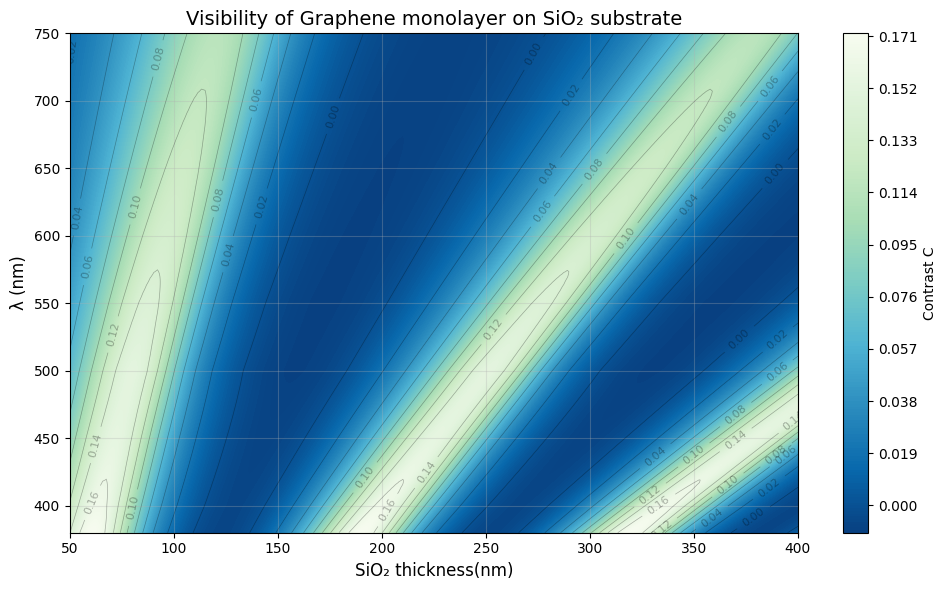

In [6]:
# Create meshgrid for wavelength and d2
wavelength_range = np.linspace(380, 750, 200)  # nm (visible spectrum)
d2_range = np.linspace(50, 400, 200)  # nm (SiO2 thickness)

D2, Lambda = np.meshgrid(d2_range, wavelength_range)

# Compute contrast for all combinations
C = np.zeros_like(Lambda)
for i in range(len(wavelength_range)):
    for j in range(len(d2_range)):
        C[i, j] = compute_contrast(d2_range[j], wavelength_range[i])

# Create the heatmap with swapped axes
fig = plt.figure(figsize=(10, 6))
im = plt.contourf(D2, Lambda, C, levels=200, cmap='GnBu_r')
plt.colorbar(im, label='Contrast C')
plt.xlabel('SiO₂ thickness(nm)', fontsize=12)
plt.ylabel('λ (nm)', fontsize=12)
plt.title('Visibility of Graphene monolayer on SiO₂ substrate', fontsize=14)
plt.grid(True, alpha=0.3)

# Add contour lines
contours = plt.contour(D2, Lambda, C, levels=10, colors='black', alpha=0.3, linewidths=0.5)
plt.clabel(contours, inline=True, fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
savefig = False
if savefig:
    fig.savefig('graphene_contrast_heatmap.png', dpi=300)

### How does hBN contrast change for different BN thickness and wavelength on 90 nm SiO2?


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Wavelength in nanometers
wavelength_data = np.array([380, 400, 450, 500, 550, 600, 650, 700, 750])

# hBN ordinary ray (perpendicular to c-axis) - for flat hBN on substrate
n_hBN_o_real = np.array([2.15, 2.13, 2.10, 2.08, 2.06, 2.05, 2.04, 2.03, 2.02])
n_hBN_o_imag = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
n_hBN_data = n_hBN_o_real + 1j * n_hBN_o_imag

# n2: Silicon dioxide (SiO₂)
n2_data = np.array([1.470, 1.468, 1.462, 1.458, 1.455, 1.453, 1.451, 1.450, 1.449]) + 0j

# n3: Silicon (Si)
n3_real = np.array([5.60, 5.57, 4.93, 4.27, 4.05, 3.94, 3.85, 3.78, 3.73])
n3_imag = np.array([0.53, 0.39, 0.16, 0.082, 0.038, 0.019, 0.010, 0.0061, 0.0042])
n3_data = n3_real + 1j * n3_imag

# Other parameters
n0 = 1  # air
d2 = 90  # nm (fixed SiO2 thickness)

In [52]:
def compute_intensity_hBN(n1_data_array, d1, wavelength):
    """
    Compute reflected intensity I for hBN with variable hBN thickness.
    
    Parameters:
    -----------
    n1_data_array : array of complex
        Wavelength-dependent refractive index data for hBN
    d1 : float
        Thickness of hBN layer in nm
    wavelength : float
        Wavelength in nm
    
    Returns:
    --------
    I : reflected intensity
    """
    
    # Interpolate n1, n2, and n3 for the given wavelength
    n1_layer = np.interp(wavelength, wavelength_data, n1_data_array.real) + \
               1j * np.interp(wavelength, wavelength_data, n1_data_array.imag)
    n2 = np.interp(wavelength, wavelength_data, n2_data.real) + 0j
    n3 = np.interp(wavelength, wavelength_data, n3_data.real) + \
         1j * np.interp(wavelength, wavelength_data, n3_data.imag)
    
    # Fresnel reflection coefficients (Eq. 2)
    r1 = (n0 - n1_layer) / (n0 + n1_layer)
    r2 = (n1_layer - n2) / (n1_layer + n2)
    r3 = (n2 - n3) / (n2 + n3)
    
    # Phase shifts
    Phi1 = 2 * np.pi * n1_layer * d1 / wavelength
    Phi2 = 2 * np.pi * n2 * d2 / wavelength
    
    # Intensity (Eq. 1)
    term1 = r1 * np.exp(1j*(Phi1 + Phi2)) + r2 * np.exp(-1j*(Phi1 - Phi2))
    term2 = r3 * np.exp(-1j*(Phi1 + Phi2)) + r1*r2*r3 * np.exp(1j*(Phi1 - Phi2))
    term3 = np.exp(1j*(Phi1 + Phi2)) + r1*r2 * np.exp(-1j*(Phi1 - Phi2))
    term4 = r1*r3 * np.exp(-1j*(Phi1 + Phi2)) + r2*r3 * np.exp(1j*(Phi1 - Phi2))
    
    I = np.abs((term1 + term2) / (term3 + term4))**2
    
    return I

In [53]:
def compute_contrast_hBN(d1, wavelength):
    """
    Compute contrast C for hBN as a function of hBN thickness and wavelength.
    
    Parameters:
    -----------
    d1 : float
        Thickness of hBN layer in nm
    wavelength : float
        Wavelength in nm
    
    Returns:
    --------
    C : contrast value
    """
    
    # Intensity with hBN
    I_with_hBN = compute_intensity_hBN(n_hBN_data, d1, wavelength)
    
    # Intensity without hBN (bare substrate)
    n_air_array = np.ones(len(wavelength_data)) + 0j
    I_without_hBN = compute_intensity_hBN(n_air_array, 0, wavelength)
    
    # Contrast (Eq. 3)
    C = (I_without_hBN - I_with_hBN) / I_without_hBN
    
    return C

In [64]:
# Create meshgrid for wavelength and hBN thickness
wavelength_range = np.linspace(380, 750, 200)  # nm (visible spectrum)
d1_range = np.linspace(0.7, 100, 200)  # nm (hBN thickness)

D1, Lambda = np.meshgrid(d1_range, wavelength_range)

# Compute contrast
C = np.zeros_like(Lambda)
for i in range(len(wavelength_range)):
    for j in range(len(d1_range)):
        C[i, j] = compute_contrast_hBN(d1_range[j], wavelength_range[i])

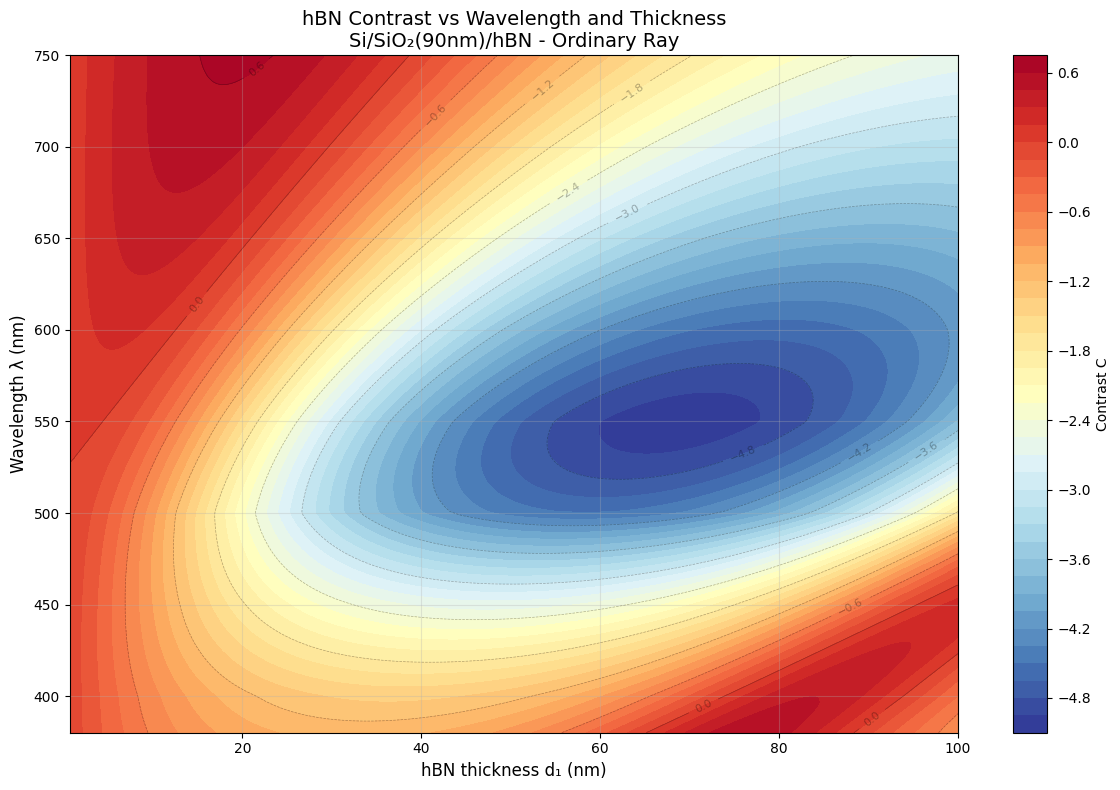

In [65]:
# Create contrast heatmap
plt.figure(figsize=(12, 8))
im = plt.contourf(D1, Lambda, C, levels=50, cmap='RdYlBu_r')
plt.colorbar(im, label='Contrast C')
plt.xlabel('hBN thickness d₁ (nm)', fontsize=12)
plt.ylabel('Wavelength λ (nm)', fontsize=12)
plt.title('hBN Contrast vs Wavelength and Thickness\nSi/SiO₂(90nm)/hBN - Ordinary Ray', fontsize=14)
plt.grid(True, alpha=0.3)

# Add contour lines
contours = plt.contour(D1, Lambda, C, levels=10, colors='black', alpha=0.3, linewidths=0.5)
plt.clabel(contours, inline=True, fontsize=8)

plt.tight_layout()
plt.show()

In [66]:
# CIE color matching functions
def wavelength_to_xyz(wavelength):
    """
    Approximate CIE 1931 color matching functions.
    Returns X, Y, Z tristimulus values for a given wavelength.
    """
    x = 1.056 * np.exp(-0.5 * ((wavelength - 599.8) / 37.9)**2) + \
        0.362 * np.exp(-0.5 * ((wavelength - 442.0) / 16.0)**2) - \
        0.065 * np.exp(-0.5 * ((wavelength - 501.1) / 20.4)**2)
    
    y = 0.821 * np.exp(-0.5 * ((wavelength - 568.8) / 46.9)**2) + \
        0.286 * np.exp(-0.5 * ((wavelength - 530.9) / 16.3)**2)
    
    z = 1.217 * np.exp(-0.5 * ((wavelength - 437.0) / 11.8)**2) + \
        0.681 * np.exp(-0.5 * ((wavelength - 459.0) / 26.0)**2)
    
    return np.maximum(0, x), np.maximum(0, y), np.maximum(0, z)

def xyz_to_rgb(X, Y, Z):
    """
    Convert XYZ to sRGB color space.
    """
    # Transformation matrix (sRGB, D65 illuminant)
    R =  3.2406 * X - 1.5372 * Y - 0.4986 * Z
    G = -0.9689 * X + 1.8758 * Y + 0.0415 * Z
    B =  0.0557 * X - 0.2040 * Y + 1.0570 * Z
    
    # Gamma correction
    def gamma_correct(c):
        c = np.where(c <= 0.0031308, 12.92 * c, 1.055 * c**(1/2.4) - 0.055)
        return np.clip(c, 0, 1)
    
    R = gamma_correct(R)
    G = gamma_correct(G)
    B = gamma_correct(B)
    
    return R, G, B

In [67]:
def compute_color_hBN(d1):
    """
    Compute the perceived color of hBN on SiO2/Si substrate.
    
    Parameters:
    -----------
    d1 : float
        Thickness of hBN layer in nm
    
    Returns:
    --------
    RGB color array
    """
    wavelengths = np.linspace(380, 750, 100)
    
    # Intensity WITH hBN
    intensities = np.zeros(len(wavelengths))
    for i, wl in enumerate(wavelengths):
        intensities[i] = compute_intensity_hBN(n_hBN_data, d1, wl)
    
    # Convert spectrum to color
    X, Y, Z = 0, 0, 0
    for wl, intensity in zip(wavelengths, intensities):
        x, y, z = wavelength_to_xyz(wl)
        X += intensity * x
        Y += intensity * y
        Z += intensity * z
    
    # Normalize
    total = X + Y + Z
    if total > 0:
        X /= total
        Y /= total  
        Z /= total
    
    # Use average intensity for brightness
    brightness = np.mean(intensities) * 3.0
    
    # Convert to RGB
    R, G, B = xyz_to_rgb(X * brightness, Y * brightness, Z * brightness)
    
    return np.array([R, G, B])

In [80]:
# Compute colors for different hBN thicknesses
d1_range_color = np.linspace(0.3, 300, 600)
colors_hBN = np.zeros((len(d1_range_color), 3))

for i, d1 in enumerate(d1_range_color):
    colors_hBN[i] = compute_color_hBN(d1)

print(f"Color range: {colors_hBN.min():.3f} to {colors_hBN.max():.3f}")

Color range: 0.296 to 1.000


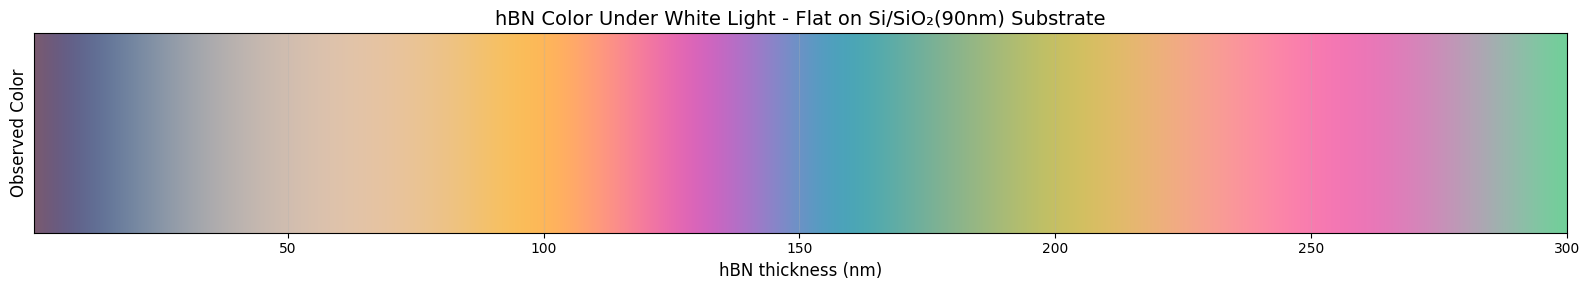

In [81]:
# Plot color variation with thickness
fig, ax = plt.subplots(1, 1, figsize=(16, 3))

color_strip = colors_hBN.reshape(1, -1, 3)

ax.imshow(color_strip, aspect='auto', extent=[d1_range_color[0], d1_range_color[-1], 0, 1])
ax.set_xlabel('hBN thickness (nm)', fontsize=12)
ax.set_ylabel('Observed Color', fontsize=12)
ax.set_title('hBN Color Under White Light - Flat on Si/SiO₂(90nm) Substrate', fontsize=14)
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()